In [ ]:
import pandas as pd 


In [50]:
import pandas as pd
filePath = r"C:\Users\Ruhaib\Downloads\IIT Stuff\Research\BiSECT Lab\Model Evaluation\Mutation Sensitivity\Results\Distances\Coding\Hyena-16k\50\distances.json"
df = pd.read_json(filePath)
df.head()

,10,20,25,35,15,5,50,45,40,30
cosine,"[0.00026515130648700004, 0.0002407972666790000...","[0.0019625540453960004, 0.001825331963597, 0.0...","[0.002791873770954, 0.002455479297504, 0.00233...","[0.004059358962832001, 0.003857485946397, 0.00...","[0.0011633893120180001, 0.0011324200419530002,...","[0.00015585411881, 8.732526668775444e-05, 0.00...","[0.007137274546689, 0.007678106345031001, 0.00...","[0.006254382359752, 0.006533124465694, 0.00633...","[0.005793011148285, 0.0046305067800730005, 0.0...","[0.0037783565448570003, 0.0034187558735250005,..."
euclidean,"[0.22497650150564802, 0.21306794657153902, 0.3...","[0.616987257817815, 0.589682838483439, 0.53143...","[0.7354352408689081, 0.686056072259132, 0.6680...","[0.8816630935102521, 0.858283931135403, 0.8528...","[0.47942654503021603, 0.468262068990118, 0.390...","[0.173826827243896, 0.12559513020739502, 0.231...","[1.158867970209485, 1.204576264567405, 1.29976...","[1.086902209221909, 1.104860773838655, 1.09020...","[1.04781640881827, 0.9398785962265551, 0.91191...","[0.8426232055506211, 0.8049497325661721, 0.667..."


In [58]:
def process_json(df):
    df = df[sorted(df.columns)]
    df = df.explode(df.columns.tolist())
    df = df.reset_index().melt(id_vars='index', var_name='Mut_percent', value_name='Distance')
    df['Mut_percent'] = df['Mut_percent'].astype(str)
    return(df)

In [51]:
print(df.columns)

df = df[sorted(df.columns)]
print(df.columns)

Index([10, 20, 25, 35, 15, 5, 50, 45, 40, 30], dtype='int64')
Index([5, 10, 15, 20, 25, 30, 35, 40, 45, 50], dtype='int64')


In [52]:
df = df.explode([x for x in range(5, 51, 5)])

In [53]:
df = df.reset_index().melt(id_vars='index', var_name='Mut_percent', value_name='Distance')
df['Mut_percent'] = df['Mut_percent'].astype(str)
df

,index,Mut_percent,Distance
0,cosine,5,0.000156
1,cosine,5,0.000087
2,cosine,5,0.00028
3,cosine,5,0.000146
4,cosine,5,0.000405
...,...,...,...
1995,euclidean,50,1.300029
1996,euclidean,50,1.061429
1997,euclidean,50,1.270985
1998,euclidean,50,1.116937


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

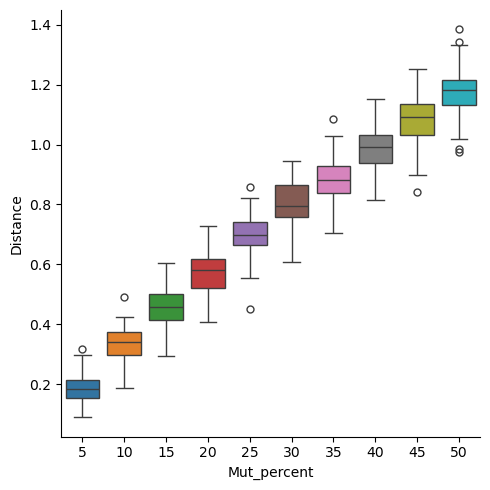

In [55]:
sns.catplot(data=df[df['index']=='euclidean'], x='Mut_percent', y="Distance", hue="Mut_percent", kind='box')


In [101]:
filePath = r"C:\Users\Ruhaib\Downloads\IIT Stuff\Research\BiSECT Lab\Model Evaluation\Mutation Sensitivity\Results\Distances\Coding\GROVER\100\distances.json"
df = pd.read_json(filePath)
df = process_json(df)

In [102]:
nc_df = pd.read_json( r"C:\Users\Ruhaib\Downloads\IIT Stuff\Research\BiSECT Lab\Model Evaluation\Mutation Sensitivity\Results\Distances\Non-coding\GROVER\100\distances.json"
)

nc_df = process_json(nc_df)

In [103]:
df['seq_type'] = 'coding'
nc_df['seq_type'] = 'non-coding'

final_df = pd.concat([df, nc_df])
final_df = final_df[final_df['index']=='euclidean']

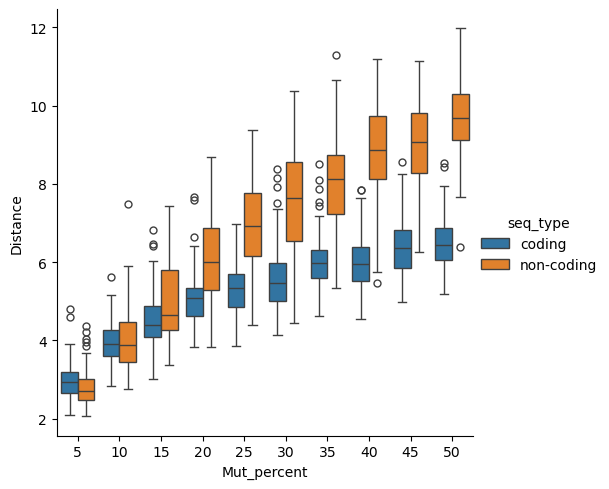

In [104]:
sns.catplot(final_df,x= 'Mut_percent',y='Distance', hue='seq_type', kind='box')

1. compositions in the og sequence - atcg
2. different characteristics of the model - tokenisation method, context length, embedding dimensionality etc
3. (prev exp) - find the change in composition, how many transitions (purines-purines/pyrimidines-pyrimidines)/transversions (cross); (AG) are purines and (TC) are pyrimidines
dictionary; A->T how many mutations and so on
more input sequences pakka
4. find pairwise number of mutations between all the YAL001C strains in the clade-based plotting experiment; do MSA
5. point mutation exp - add original base, and the position too.
6. use only the models which give higher distances for non coding sequences.

<Axes: xlabel='Distance', ylabel='Count'>

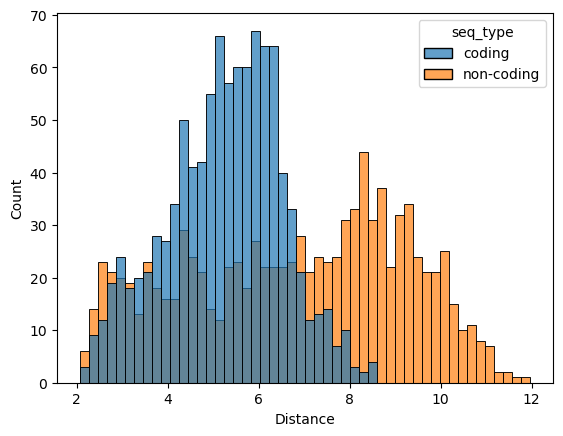

In [105]:
sns.histplot(final_df, x='Distance',  bins=50, hue='seq_type', alpha=0.7)
